# Exercise 2. Annotate and Classify on Few Examples
So far we have been working with pre-labeled datasets. However, many interesting NLP questions are also to be found in datasets that do not have any labels!

**Let's imagine that we want to expand our student questions dataset** with *history* and *social science* questions:

> Who led the civil rights movement in the United States?    
>   A. Nelson Mandela       
>   B. Martin Luther King Jr.   
>   C. Malcolm X   
>   D. Rosa Parks   

## 2.1 Let's Annotate!
We can take a break from scripts and move back into notebooks now :)

:::{admonition} HANDS-ON
:class: red
ChatGPT has generated new questions that you need to annotate as "Social Science" or "History". Read through the questions below carefully and annotate by yourself. Then compare with a friend. Consider:
- Do you agree on the annotations?
- Were there any difficult ones?

I have tried to design the questions so that there is 8 per class, but you might disagree here!
:::


Copy the dictionary of questions into your own notebook and replace "LABEL" with `"Social Science"` or `"History"`:

In [179]:
questions = {
    "Societies collapse when their political institutions fail. Do you agree?": "LABEL",
    "Can a country have elections but not be democratic? Argue for your answer.": "LABEL",
    "Who led the civil rights movement in the United States? \nA. Nelson Mandela\nB. Martin Luther King Jr.\nC. Malcolm X\nD. Rosa Parks": "LABEL",
    "When empires expand, is it always for economic reasons? Discuss with examples.": "LABEL",
    "Which organization was formed after World War II to promote peace and cooperation?\nA. League of Nations\nB. NATO\nC. United Nations\nD. European Union": "LABEL",
    "What is the main difference between capitalism and socialism?": "LABEL",
    "Nationalism can emerge from social institutions or historical events. Which factor do you think has been more influential in shaping modern states?": "LABEL",
    "Social progress does not always follow technological progress. Provide one example where technology increased inequality rather than reducing it.": "LABEL",
    "Which factor most contributed to rapid urban growth in 19th-century Europe?\nA. Agricultural decline\nB. Industrial job opportunities\nC. Rise of universities\nD. Religious reforms": "LABEL",
    "Social movements can succeed through protests, legal change, or public opinion. Which has been most effective? Explain with one example.": "LABEL",
    "How did the introduction of cash crops in colonial Africa reshape local social structures?\nA. Increased wealth for local farmers\nB. Strengthened traditional hierarchies\nC. Created labor inequalities\nD. All of the above": "LABEL",
    "Which factor contributed most to the spread of Islam across Africa and Asia before 1500 CE?\nA. Trade networks\nB. Military conquest\nC. Cultural assimilation\nD. Missionary activity": "LABEL",
    "Which technological innovation in the Indian Ocean trade had the largest societal effect before 1600 CE?\nA. Lateen sails\nB. Compass navigation\nC. Shipbuilding techniques\nD. Port infrastructure": "LABEL",
    "Which has a stronger influence on social behavior: historical narratives or contemporary media? Explain briefly.": "LABEL",
    "Which is more effective in promoting public health: top-down government interventions or grassroots social initiatives? Explain.": "LABEL",
    "Which factor most influences political participation in modern societies?\nA. Economic stability\nB. Education\nC. Media exposure\nD. Social networks": "LABEL"
}

:::{admonition} QUESTION
:class: red
Before you move on, list any concerns that there may be with synthetically generated questions like this. Discuss with a friend.   

During this discussion, it might be worth to take a look at how I decided to create these questions.
:::

:::{admonition} LLM FRAMING: How did I create the questions with ChatGPT?
:class: dropdown, fuchsia
I created these questions with ChatGPT (in the interface) by giving it: 
- Instructions about the original dataset (name of the dataset, on Kaggle, mix of multiple choice Q's, open-ended questions etc.)
- Instructions for what I wanted (history + social science questions, ideally some edge-cases)
- Four examples of questions from the original dataset

I also wrote in the same thread for a long time ... 
- I got ChatGPT to generate a lot of examples, then picked the ones that I liked the most - for the purpose of this class!
- I provided extra instructions such as "give me a few longer questions"

Synthetic data creation is not typically as trivial as my experimenting! This is a huge field on the rise with many considerations on how to do it best.
:::

### My Solution
My annotations are below. Do we disagree? Regardless, I suggest you stick to yours and compare whether performance is different with your annotations compared to mine :) 

In [180]:
# MY ANNOTATIONS
questions = {
    "Societies collapse when their political institutions fail. Do you agree?": "Social Science",
    "Can a country have elections but not be democratic? Argue for your answer.": "Social Science",
    "Who led the civil rights movement in the United States? \nA. Nelson Mandela\nB. Martin Luther King Jr.\nC. Malcolm X\nD. Rosa Parks": "History",
    "When empires expand, is it always for economic reasons? Discuss with examples.": "History",
    "Which organization was formed after World War II to promote peace and cooperation?\nA. League of Nations\nB. NATO\nC. United Nations\nD. European Union": "History",
    "What is the main difference between capitalism and socialism?": "Social Science",
    "Nationalism can emerge from social institutions or historical events. Which factor do you think has been more influential in shaping modern states?": "History",
    "Social progress does not always follow technological progress. Provide one example where technology increased inequality rather than reducing it.": "Social Science",
    "Which factor most contributed to rapid urban growth in 19th-century Europe?\nA. Agricultural decline\nB. Industrial job opportunities\nC. Rise of universities\nD. Religious reforms": "History",
    "Social movements can succeed through protests, legal change, or public opinion. Which has been most effective? Explain with one example.": "Social Science",
    "How did the introduction of cash crops in colonial Africa reshape local social structures?\nA. Increased wealth for local farmers\nB. Strengthened traditional hierarchies\nC. Created labor inequalities\nD. All of the above": "History",
    "Which factor contributed most to the spread of Islam across Africa and Asia before 1500 CE?\nA. Trade networks\nB. Military conquest\nC. Cultural assimilation\nD. Missionary activity": "History",
    "Which technological innovation in the Indian Ocean trade had the largest societal effect before 1600 CE?\nA. Lateen sails\nB. Compass navigation\nC. Shipbuilding techniques\nD. Port infrastructure": "History",
    "Which has a stronger influence on social behavior: historical narratives or contemporary media? Explain briefly.": "Social Science",
    "Which is more effective in promoting public health: top-down government interventions or grassroots social initiatives? Explain.": "Social Science",
    "Which factor most influences political participation in modern societies?\nA. Economic stability\nB. Education\nC. Media exposure\nD. Social networks": "Social Science"
}

## 2.2 Setup: Install Additional Packages
Please download the packages below (in `venv` or in UCloud) in your terminal:
```bash
pip install sentence-transformers datasets transformers setfit matplotlib scikit-learn
```

:::{admonition} Download in Jupyter
:class: dropdown, tip
Remember, you can also download the packages in Jupyter with the `%pip` magic command as we have done in previous classes.
:::

I'll re-import everything (since you worked in a script last), but as always, import only what you need

In [181]:
from pathlib import Path
from datasets import load_dataset, ClassLabel, Dataset, concatenate_datasets, Value # note I have added Dataset, ConcatenateDataset and Value
from setfit import SetFitModel, Trainer, TrainingArguments

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix 
import matplotlib.pyplot as plt

## 2.3 Prepare Data

### Your Turn: Create Numerical Labels

You should now have dictionary `questions` with a `question` as the `key` and its text label `Social Science` or `History` as the value. We also want numerical variables. Since we have labels 0 to 3 (for the first four classes), we need labels 4 to 5.

:::{admonition} HANDS-ON
:class: red
To recap for loops, create a numerical label mapping! You can:
- Define an empty list outside of the loop called `numeric_labels`
- Define a for loop that goes through each value (text label) of the dictionary
    - Checks if the value is `History` and appends the number `4` to `numeric_labels`
    - Checks if the value is `Social Science` and appends the number `5`
    - Has a final `else` statement that appends `-1` AND prints "Something went wrong, appending label -1"

*Optionally, you could consider if there are other ways than for loops for this!*
:::

:::{admonition} HELP. Dictionaries? Values?
:class: tip, dropdown
A dictionary in Python can store values in key:value pairs such as. Let's imagine a takeaway order:
```python
takeaway = { 
            "Mina": "Pho Vegan",
            "Anton": "Banh Hoi",
            "Laura": "Veggie Gyoza"
            }
```

We are actually throwing a party! But not all friends have submitted their wish. Let's print all the names of those who have ordered:
```python
print(takeaway.keys())
```

When ordering, we probably don't care who needs what, we just want all the orders to be able to call the restaurant: 
```python
print(takeaway.values())
```

We can also access keys and values by iterating over them
```python
for order in takeway.values()
    print(order)
```

We might also want to convert these to a list:
```python
orders = list(takeaway.values())
```
:::


#### Solution

In [182]:
# create a list to store numeric labels
numeric_labels = []

# loop through the values and use if statements to assign numbers
for label in questions.values():
    if label == "History":
        numeric_labels.append(4)
    elif label == "Social Science":
        numeric_labels.append(5)
    else:
        print(f"[WARNING] Unknown label: {label}. Assigning -1.")
        numeric_labels.append(-1)  # or any number for unknown labels

### Create Dataset from Annotations

Now that you have the variable `numeric_labels`, let's create a new dataset with our data!

In [183]:
# format suitable for Dataset
new_train_data = {
    "text": list(questions.keys()),
    "label": list(numeric_labels) ,  
    "label_text": list(questions.values())   
}

new_train_ds = Dataset.from_dict(new_train_data)

### Load New Validation Set

For the validation dataset, I have cheated a little bit. I made ChatGPT create and annotate a dataset:

In [184]:
path = Path.cwd()
data_path = path.parents[1] / "resources" / "data" / "history_socsci_qs_val.csv"
new_val_ds = load_dataset("csv", data_files=str(data_path))["train"]

:::{admonition} Validate your synthetic datasets!
:class: dropdown, important
For simplicity during class, we are not exploring this dataset. However, such a synthetic dataset should be validated to at least *some* extent. Ideally, you should be able to show and reflect upon any potential issues. 

This is also why it is smart to annotate synthetic data yourself - then you have spent time looking through the data!
:::

How many examples do we have? 

In [185]:
print(f"New validation dataset size: {len(new_val_ds)}")

New validation dataset size: 64


### Combine with Previous Data

Let's combine our new annotated data with the original dataset. I'll load it in my notebook:

In [186]:
data_path = path.parents[1] / "resources" / "data" / "hf" # path for huggingface datasets (so we don't have to redownload them every time)
ds = load_dataset("SetFit/student-question-categories", split="train", cache_dir=data_path)

Repo card metadata block was not found. Setting CardData to empty.


**Let's downsample to match our 16 history/social science training and 64 validation examples**. With 4 classes in the original dataset, we'll use 4×8 samples for training and 4x32 for the validation.

In [187]:
num_classes = 4
ds = ds.cast_column("label", ClassLabel(num_classes=num_classes)) # label to straitfy

ds_downsampled = ds.train_test_split(train_size=32,test_size=128, seed=42, stratify_by_column="label")

After splitting, we reset `cast_column` to later combine with 2 new classes:

In [188]:
ds_downsampled = ds_downsampled.cast_column("label", Value("int64"))

Combine:

In [189]:
train_ds = concatenate_datasets([ds_downsampled["train"], new_train_ds])
val_ds = concatenate_datasets([ds_downsampled["test"], new_val_ds])

Let's shuffle them:

In [190]:
train_ds = train_ds.shuffle(seed=42)
val_ds = val_ds.shuffle(seed=42)

:::{admonition} HANDS-ON
:class: red
In your notebook, make sure to run the data workflow before proceeding as you'll need it for experimenting with SetFit later.
:::

## 2.4 Few-Shot Learning with SetFit 
We'll use the package `setfit`, developed by HuggingFace, to do *few-shot* learning! We'll use the small `all-MiniLM-L6-v2` model:

In [191]:
model = SetFitModel.from_pretrained(
    "sentence-transformers/all-MiniLM-L6-v2", trust_remote_code=True,
)

model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.


:::{admonition} How does `Setfit` differ from `Transformers`? 
:class: tip, dropdown
`SetFit`, also from Hugging Face, is designed for few-shot learning tasks. *Few-shot* refers to learning from limited examples!

Instead of fine-tuning large `transformer` models directly, it builds on `sentence-transformers` to learn from sentence embeddings. Training involves comparing sentence pairs and optimizing similarity scores to generalize from very few examples.

[Read more about it here.](https://huggingface.co/blog/setfit#how-does-it-work)
:::

:::{admonition} What is *all-MiniLM-L6-v2* ? 
:class: tip, dropdown
It is a version of *MiniLM* fine-tuned specifically on *sentence embeddings*. `Mini-LM` is `distilled` from `BERT-BASE`. See {cite:t}`wang_minilm_2020` ([arXiv](https://arxiv.org/pdf/2002.10957)).

**Distilliation** is a process of taking a larger language model and compressing it to a smaller size, often using a "teacher" model in some way or another (the approach differs greatly!!) 
:::

### Train Config

It gets a bit confusing here as `Trainer` (and `TrainingArguments`) from `setfit` is similar but not identical in parameters to `transformers.Trainer`:

In [192]:
output_dir = path.parents[0] / "training" / "minilm_setfit_history_socsci"

args = TrainingArguments(
    batch_size=8,
    output_dir=output_dir,
    num_epochs=1,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    metric="accuracy",
    column_mapping={"text": "text", "label": "label"} # map dataset columns to text/label
    )

Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset


In [193]:
# NB. CELL IS REMOVED FROM BOOK! - just to remove annoying warning from book on the output below!
import warnings
warnings.filterwarnings("ignore")

### Train and Eval

In [194]:
trainer.train()

***** Running training *****
  Num unique pairs = 1886
  Batch size = 8
  Num epochs = 1


Step,Training Loss
1,0.370300
50,0.169100
100,0.081400
150,0.056400
200,0.032400


In [195]:
trainer.evaluate()

***** Running evaluation *****


{'accuracy': 0.7708333333333334}

Hmm ! It seems to be doing quite well, even with a few hand-annotated examples, but can we get the accuracy a bit up?

### Your Turn: Experiment with Model Settings
:::{admonition} HANDS-ON
:class: red
Go look at SetFit's documentation for its [TrainingArguments](https://huggingface.co/docs/setfit/main/en/reference/trainer#setfit.TrainingArguments). Is there anything you can tweak or tune that might make the model performance go up? Run the code a few times with diff. configurations!

I recommend experiementing with `num_epochs`, but try a few others as well!
:::

## 2.5 More Fine-Grained Eval
Let's get individual predictions:

In [196]:
y_pred = trainer.model.predict(val_ds["text"])
print(y_pred)

tensor([4, 2, 1, 5, 1, 2, 4, 3, 5, 4, 1, 3, 1, 4, 1, 2, 4, 1, 1, 4, 1, 1, 1, 4,
        5, 3, 1, 2, 1, 3, 4, 1, 5, 1, 3, 3, 5, 5, 1, 1, 1, 3, 2, 2, 4, 1, 1, 5,
        5, 5, 3, 3, 1, 4, 3, 5, 3, 1, 3, 5, 3, 1, 1, 3, 3, 4, 2, 4, 5, 1, 4, 3,
        3, 1, 2, 1, 4, 5, 5, 1, 4, 2, 2, 4, 1, 5, 1, 1, 4, 5, 1, 2, 5, 5, 3, 4,
        1, 2, 3, 4, 2, 3, 1, 5, 2, 5, 3, 3, 1, 1, 1, 2, 2, 1, 1, 5, 1, 1, 2, 1,
        2, 4, 4, 2, 1, 5, 1, 5, 3, 2, 4, 1, 1, 5, 2, 2, 3, 1, 1, 5, 3, 3, 4, 3,
        2, 5, 4, 4, 3, 4, 2, 4, 1, 5, 3, 3, 4, 2, 5, 1, 1, 1, 4, 2, 3, 3, 5, 2,
        3, 2, 3, 3, 3, 3, 1, 4, 5, 2, 2, 2, 1, 5, 1, 2, 2, 4, 5, 2, 4, 3, 1, 4])


In [197]:
y_true = val_ds["label"][:] # for some reason I need [:] to get all values

Let's plot as a confusion matrix:

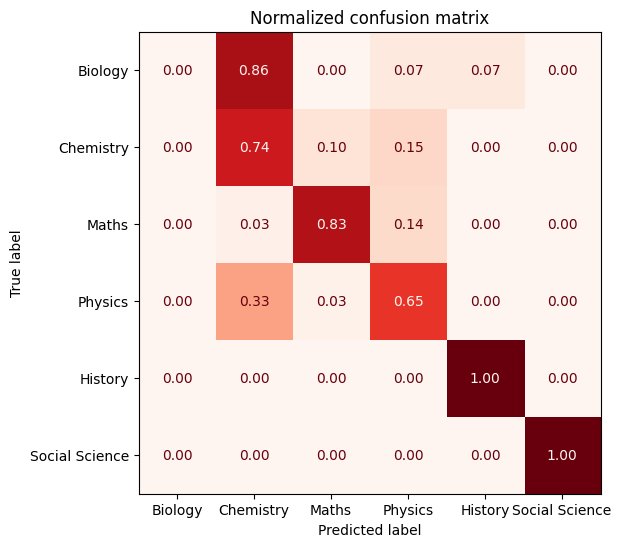

In [198]:
labels = ["Biology", "Chemistry", "Maths", "Physics", "History", "Social Science"]

cm = confusion_matrix(y_true, y_pred, normalize="true")
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Reds", values_format=".2f", ax=ax, colorbar=False)
plt.title("Normalized confusion matrix") 
plt.show()

### Your Turn: Investigate Biology
:::{admonition} HANDS-ON
:class: red
For some interesting reason, the model never predicts Biology (0). All of them are predicted as Chemistry. Is this just a fluke? Or is something wrong with our data/model? Investigate this:

**TASK A: Look at Data**
- Filter the DS to only include rows where `label` is 0 (or Biology). Look at the texts - is something weird? Do the same for `Chemistry` to compare the two (do they seem very similar?).

**TASK B: Make it Easy to Plot**
- Wrap my confusion matrix code as a function called `plot_confusion_matrix`

**TASK C: Plot Your Best SetFit training(s)**
- You have just experimented with `SetFit`'s hyper-parameters. Plot your chosen hyper-parameter configuration (or a few of them) and see whether it improves scores for biology.
:::

#### Solutions
##### Task A
Before proceeding to the solution, check the hint:
:::{admonition} HINT
:class: tip, dropdown
To filter: Read and see the usage for the `ds.filter()` method in the [docs](https://huggingface.co/docs/datasets/v4.2.0/en/package_reference/main_classes#datasets.Dataset.filter)

Use a `for loop` to iterate over your filtered `ds` and print `row["text]`.
:::


In [ ]:
biology_only = val_ds.filter(lambda row: row["label"] == 0)

for row in biology_only:
    print(row["text"])

# do the same for chemistry

Choose the correct answer from the
alternatives given
Aldosterone causes the:
A. kidneys to release renin
B. kidneys to reabsorb sodium
c. blood volume to increase
D. all of the above
The sex chromosomes of both male and
female are respectively
A. YY, XX
в. \( Y X, X Y \)
c. \( x y, x x \)
D. All of the above
Three water samples namely river water, untreated sewage water and secondary effluent discharged from a sewage treatment plant were subjected to BOD test. The samples were labelled \( A, B \) and \( C ; \) but the laboratory attendant did not note which was which
The BOD values of the three samples \( A, B \) and \( C \) were recorded as \( \mathbf{2 0} \boldsymbol{m g} / \boldsymbol{L}, \mathbf{8 m g} / \boldsymbol{L} \) and \( \mathbf{4 0 0} \boldsymbol{m g} / \boldsymbol{L} \)
respectively. Which sample of the water is most polluted? Can you assign the correct label to each assuming the river water is relatively clean?
in plant cell and in
mannalian cells are non-nucleated in
m

##### Task B

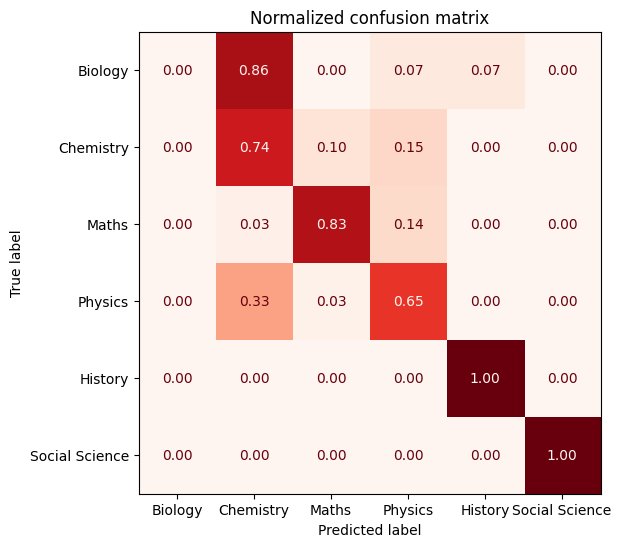

In [200]:
def plot_confusion_matrix(y_pred: list, y_true: list, labels: list, cmap: str = "Reds", figsize: tuple = (6, 6)):
    """
    Plot a confusion matrix given true and predicted labels.

    Args:
        y_pred: Predicted labels.
        y_true: True labels.
        labels: List of label names for display.
        cmap: Colormap for the plot. Default is "Reds".
        figsize: Figure size. Default is (6, 6).

    Returns:
        fig: Matplotlib figure object containing the confusion matrix plot.
    """
    # use sklearn to compute confusion matrix
    cm = confusion_matrix(y_true, y_pred, normalize="true")

    # plot using matplotlib and sklearn's ConfusionMatrixDisplay
    fig, ax = plt.subplots(figsize=figsize)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=cmap, values_format=".2f", ax=ax, colorbar=False)
    plt.title("Normalized confusion matrix") 

    return fig

labels = ["Biology", "Chemistry", "Maths", "Physics", "History", "Social Science"]
fig = plot_confusion_matrix(y_pred, y_true, labels)

### Food for Thought 
:::{admonition} QUESTION
:class: red
Another curious observation: all synthetically generated History and Social Science questions are classified correctly. Is the model truly that good, or is there an issue with the data?

<details>
<summary>ANSWER</summary>
It’s hard to say for sure without better validation of both the training and validation sets of the history/social science questions - as I also mentioned earlier in this page. 
<br><br>
One likely explanation is that the synthetic data has some cues that ML models pick up on, like limited lexical variation or repeated keywors that makes the questions easier for the model to pick up on than naturalistic data.
<br><br>
Either way, it’s a curious and interesting observation!
</details>
:::